In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os

ROOT = "/content/drive/MyDrive/Underwater_Project"

folders = [
    "01_Dataset",
    "02_Balanced",
    "03_Augmented",
    "04_CLAHE",
    "05_Otsu",
    "06_1bit",
    "07_3bit",
    "models",
    "results",
    "scripts",
    "report"
]

for folder in folders:
    os.makedirs(os.path.join(ROOT, folder), exist_ok=True)

print("Project folders created!")

print("\nContents:")
print(os.listdir(ROOT))

Project folders created!

Contents:
['02_Balanced', 'report', 'scripts', '06_1bit', '05_Otsu', 'datasets', '03_Augmented', 'models', '01_Dataset', '04_CLAHE', '07_3bit', 'results']


In [ ]:
!pip install -q gdown


In [ ]:
import gdown

file_id = "1w-bWevH7jFs7A1bIBlAOvXOxe2OFSHHs"
output = "/content/drive/MyDrive/Underwater_Project/datasets/raw/DUO.zip"

gdown.download(id=file_id, output=output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1w-bWevH7jFs7A1bIBlAOvXOxe2OFSHHs
From (redirected): https://drive.google.com/uc?id=1w-bWevH7jFs7A1bIBlAOvXOxe2OFSHHs&confirm=t&uuid=70bf81e5-abec-4f8c-88e5-709bd617af27
To: /content/drive/MyDrive/Underwater_Project/datasets/raw/DUO.zip
100%|██████████| 2.94G/2.94G [00:39<00:00, 74.4MB/s]


'/content/drive/MyDrive/Underwater_Project/datasets/raw/DUO.zip'

In [ ]:
import zipfile

with zipfile.ZipFile("/content/drive/MyDrive/Underwater_Project/datasets/raw/DUO.zip", "r") as zip_ref:
    zip_ref.extractall("/content/drive/MyDrive/Underwater_Project/datasets/raw")

print("✅ DUO extracted successfully!")

✅ DUO extracted successfully!


In [ ]:
import os

ann_path = "/content/drive/MyDrive/Underwater_Project/datasets/raw/DUO/annotations"

print("Annotation files:")
for f in sorted(os.listdir(ann_path)):
    print(f)

Annotation files:
instances_test.json
instances_train.json


In [ ]:
import os
import json
from PIL import Image
from tqdm import tqdm

# ==========================
# Paths
# ==========================
BASE = "/content/drive/MyDrive/Underwater_Project/datasets/raw/DUO"

TRAIN_JSON = os.path.join(BASE, "annotations", "instances_train.json")
TEST_JSON  = os.path.join(BASE, "annotations", "instances_test.json")

TRAIN_IMG = os.path.join(BASE, "images", "train")
TEST_IMG  = os.path.join(BASE, "images", "test")

OUT = "/content/drive/MyDrive/Underwater_Project/datasets/cropped"

# ==========================
# Crop Function
# ==========================
def crop_dataset(json_file, image_dir, split):

    with open(json_file, "r") as f:
        coco = json.load(f)

    # Category ID -> Name
    categories = {c["id"]: c["name"] for c in coco["categories"]}

    # Image ID -> File Name
    image_map = {img["id"]: img["file_name"] for img in coco["images"]}

    print(f"\nProcessing {split} set...")

    counter = 0

    for ann in tqdm(coco["annotations"]):

        image_name = image_map[ann["image_id"]]
        category = categories[ann["category_id"]]

        img_path = os.path.join(image_dir, image_name)

        if not os.path.exists(img_path):
            continue

        img = Image.open(img_path).convert("RGB")

        x, y, w, h = ann["bbox"]

        x = int(x)
        y = int(y)
        w = int(w)
        h = int(h)

        crop = img.crop((x, y, x+w, y+h))

        save_dir = os.path.join(OUT, split, category)
        os.makedirs(save_dir, exist_ok=True)

        crop.save(os.path.join(save_dir, f"{counter}.jpg"))

        counter += 1

    print(f"Finished {split}: {counter} objects saved.")

# ==========================
# Run
# ==========================

crop_dataset(TRAIN_JSON, TRAIN_IMG, "train")
crop_dataset(TEST_JSON, TEST_IMG, "test")

print("\n✅ Cropping Complete!")


Processing train set...


100%|██████████| 63998/63998 [44:25<00:00, 24.01it/s]


Finished train: 63998 objects saved.

Processing test set...


100%|██████████| 10517/10517 [07:50<00:00, 22.37it/s]

Finished test: 10517 objects saved.

✅ Cropping Complete!


In [ ]:
import os

base = "/content/drive/MyDrive/Underwater_Project/datasets/cropped"

for split in ["train", "test"]:
    print(f"\n{'='*40}")
    print(split.upper())
    print('='*40)

    split_path = os.path.join(base, split)

    total = 0
    for cls in sorted(os.listdir(split_path)):
        count = len(os.listdir(os.path.join(split_path, cls)))
        total += count
        print(f"{cls:<15}: {count}")

    print(f"\nTotal images: {total}")


TRAIN
echinus        : 42955
holothurian    : 6808
scallop        : 1707
starfish       : 12528

Total images: 63998

TEST
echinus        : 7201
holothurian    : 1079
scallop        : 217
starfish       : 2020

Total images: 10517


In [ ]:
import os
import random
import shutil

random.seed(42)

SOURCE = "/content/drive/MyDrive/Underwater_Project/datasets/cropped"
DEST = "/content/drive/MyDrive/Underwater_Project/datasets/balanced"

# Remove old balanced dataset if it exists
if os.path.exists(DEST):
    shutil.rmtree(DEST)

for split in ["train", "test"]:

    split_src = os.path.join(SOURCE, split)
    split_dst = os.path.join(DEST, split)

    os.makedirs(split_dst, exist_ok=True)

    # Count images in each class
    class_counts = {}

    for cls in sorted(os.listdir(split_src)):
        cls_path = os.path.join(split_src, cls)
        images = [
            f for f in os.listdir(cls_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]
        class_counts[cls] = len(images)

    # Smallest class
    min_count = min(class_counts.values())

    print(f"\n{split.upper()}")
    print(f"Balancing every class to {min_count} images\n")

    # Sample images
    for cls in sorted(os.listdir(split_src)):

        src_cls = os.path.join(split_src, cls)
        dst_cls = os.path.join(split_dst, cls)

        os.makedirs(dst_cls, exist_ok=True)

        images = [
            f for f in os.listdir(src_cls)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        selected = random.sample(images, min_count)

        for img in selected:
            shutil.copy2(
                os.path.join(src_cls, img),
                os.path.join(dst_cls, img)
            )

        print(f"{cls:<15}: {min_count}")

print("\n✅ Balanced dataset created successfully!")


TRAIN
Balancing every class to 1707 images

echinus        : 1707
holothurian    : 1707
scallop        : 1707
starfish       : 1707

TEST
Balancing every class to 217 images

echinus        : 217
holothurian    : 217
scallop        : 217
starfish       : 217

✅ Balanced dataset created successfully!


In [ ]:
import os

BASE = "/content/drive/MyDrive/Underwater_Project/datasets/balanced"

for split in ["train", "test"]:
    print(f"\n{split.upper()}")

    total = 0

    for cls in sorted(os.listdir(os.path.join(BASE, split))):
        n = len(os.listdir(os.path.join(BASE, split, cls)))
        total += n
        print(f"{cls:<15}: {n}")

    print(f"Total images = {total}")


TRAIN
echinus        : 1707
holothurian    : 1707
scallop        : 1707
starfish       : 1707
Total images = 6828

TEST
echinus        : 217
holothurian    : 217
scallop        : 217
starfish       : 217
Total images = 868


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

INPUT_DIR = "/content/drive/MyDrive/Underwater_Project/datasets/balanced"
OUTPUT_DIR = "/content/drive/MyDrive/Underwater_Project/datasets/resized"

TARGET_SIZE = 256

for split in ["train", "test"]:

    for cls in sorted(os.listdir(os.path.join(INPUT_DIR, split))):

        src = os.path.join(INPUT_DIR, split, cls)
        dst = os.path.join(OUTPUT_DIR, split, cls)

        os.makedirs(dst, exist_ok=True)

        files = [
            f for f in os.listdir(src)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        print(f"{split}/{cls}")

        for file in tqdm(files):

            img = cv2.imread(os.path.join(src, file))

            h, w = img.shape[:2]

            scale = TARGET_SIZE / max(h, w)

            new_w = int(w * scale)
            new_h = int(h * scale)

            resized = cv2.resize(
                img,
                (new_w, new_h),
                interpolation=cv2.INTER_AREA
            )

            canvas = np.zeros((TARGET_SIZE, TARGET_SIZE, 3), dtype=np.uint8)

            x = (TARGET_SIZE - new_w) // 2
            y = (TARGET_SIZE - new_h) // 2

            canvas[y:y+new_h, x:x+new_w] = resized

            cv2.imwrite(os.path.join(dst, file), canvas)

print("✅ Letterbox resizing complete!")

train/echinus


100%|██████████| 1707/1707 [00:44<00:00, 38.59it/s]


train/holothurian


100%|██████████| 1707/1707 [00:47<00:00, 36.14it/s]


train/scallop


...

test/scallop


100%|██████████| 217/217 [00:04<00:00, 44.82it/s]


test/starfish


100%|██████████| 217/217 [00:04<00:00, 45.18it/s]

✅ Letterbox resizing complete!


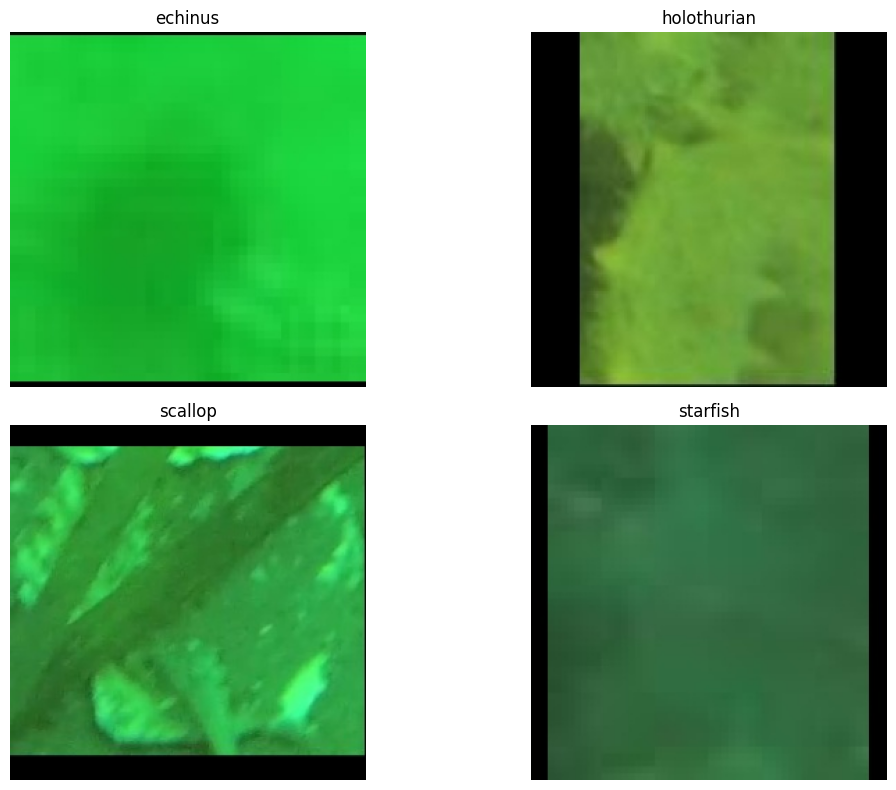

In [ ]:
import matplotlib.pyplot as plt
import cv2
import os
import random

BASE = "/content/drive/MyDrive/Underwater_Project/datasets/resized/train"

classes = sorted(os.listdir(BASE))

plt.figure(figsize=(12,8))

for i, cls in enumerate(classes):

    img_name = random.choice(os.listdir(os.path.join(BASE, cls)))

    img = cv2.imread(os.path.join(BASE, cls, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
!pip install -q albumentations

In [ ]:
import os
import cv2
import shutil
from tqdm import tqdm
import albumentations as A

INPUT_DIR = "/content/drive/MyDrive/Underwater_Project/datasets/resized"
OUTPUT_DIR = "/content/drive/MyDrive/Underwater_Project/datasets/augmented"

transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Affine(
        scale=(0.9, 1.1),
        translate_percent=(-0.1, 0.1),
        rotate=(-15, 15),
        p=0.8
    ),
    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=0.8
    )
])

# --------------------------
# TRAIN
# --------------------------

train_in = os.path.join(INPUT_DIR, "train")
train_out = os.path.join(OUTPUT_DIR, "train")

for cls in sorted(os.listdir(train_in)):

    os.makedirs(os.path.join(train_out, cls), exist_ok=True)

    images = sorted(os.listdir(os.path.join(train_in, cls)))

    print(f"\nProcessing {cls}")

    for img_name in tqdm(images):

        img_path = os.path.join(train_in, cls, img_name)
        img = cv2.imread(img_path)

        # Save original
        shutil.copy2(
            img_path,
            os.path.join(train_out, cls, "original_" + img_name)
        )

        # Save augmented
        aug = transform(image=img)["image"]

        cv2.imwrite(
            os.path.join(train_out, cls, "aug_" + img_name),
            aug
        )

# --------------------------
# TEST (No augmentation)
# --------------------------

test_in = os.path.join(INPUT_DIR, "test")
test_out = os.path.join(OUTPUT_DIR, "test")

for cls in sorted(os.listdir(test_in)):

    src = os.path.join(test_in, cls)
    dst = os.path.join(test_out, cls)

    shutil.copytree(src, dst, dirs_exist_ok=True)

print("\n✅ Augmentation completed!")


Processing echinus


100%|██████████| 1707/1707 [01:21<00:00, 20.82it/s]



Processing holothurian


100%|██████████| 1707/1707 [01:20<00:00, 21.19it/s]



Processing scallop


100%|██████████| 1707/1707 [01:21<00:00, 21.02it/s]



Processing starfish


100%|██████████| 1707/1707 [01:24<00:00, 20.24it/s]



✅ Augmentation completed!


In [ ]:
import os

BASE = "/content/drive/MyDrive/Underwater_Project/datasets/augmented"

for split in ["train", "test"]:

    print(f"\n{split.upper()}")

    total = 0

    for cls in sorted(os.listdir(os.path.join(BASE, split))):

        n = len(os.listdir(os.path.join(BASE, split, cls)))
        total += n

        print(f"{cls:<15}: {n}")

    print(f"Total = {total}")


TRAIN
echinus        : 3414
holothurian    : 3414
scallop        : 3414
starfish       : 3414
Total = 13656

TEST
echinus        : 217
holothurian    : 217
scallop        : 217
starfish       : 217
Total = 868


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

INPUT_DIR = "/content/drive/MyDrive/Underwater_Project/datasets/augmented"
OUTPUT_DIR = "/content/drive/MyDrive/Underwater_Project/datasets/noisy"

MEAN = 0
STD_DEV = 8

np.random.seed(42)

for split in ["train", "test"]:

    for cls in sorted(os.listdir(os.path.join(INPUT_DIR, split))):

        src = os.path.join(INPUT_DIR, split, cls)
        dst = os.path.join(OUTPUT_DIR, split, cls)

        os.makedirs(dst, exist_ok=True)

        files = [
            f for f in os.listdir(src)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        print(f"{split}/{cls}")

        for file in tqdm(files):

            img = cv2.imread(os.path.join(src, file))

            noise = np.random.normal(
                MEAN,
                STD_DEV,
                img.shape
            ).astype(np.float32)

            noisy = img.astype(np.float32) + noise
            noisy = np.clip(noisy, 0, 255).astype(np.uint8)

            cv2.imwrite(
                os.path.join(dst, file),
                noisy
            )

print("✅ White Gaussian Noise added successfully!")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Underwater_Project/datasets/augmented/train'

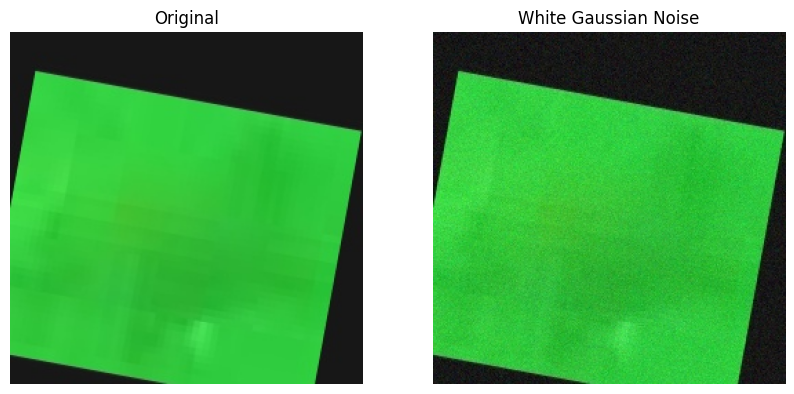

In [ ]:
import matplotlib.pyplot as plt
import cv2
import random
import os

base_original = "/content/drive/MyDrive/Underwater_Project/datasets/augmented/train"
base_noisy = "/content/drive/MyDrive/Underwater_Project/datasets/noisy/train"

cls = random.choice(sorted(os.listdir(base_original)))
img_name = random.choice(os.listdir(os.path.join(base_original, cls)))

orig = cv2.cvtColor(
    cv2.imread(os.path.join(base_original, cls, img_name)),
    cv2.COLOR_BGR2RGB
)

noisy = cv2.cvtColor(
    cv2.imread(os.path.join(base_noisy, cls, img_name)),
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(orig)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(noisy)
plt.title("White Gaussian Noise")
plt.axis("off")

plt.show()

In [ ]:
clipLimit = 2.0
tileGridSize = (8, 8)

In [ ]:
import os
import cv2
from tqdm import tqdm

INPUT_DIR = "/content/drive/MyDrive/Underwater_Project/datasets/noisy"
OUTPUT_DIR = "/content/drive/MyDrive/Underwater_Project/datasets/enhanced_wgn_clahe"
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

for split in ["train", "test"]:

    for cls in sorted(os.listdir(os.path.join(INPUT_DIR, split))):

        src = os.path.join(INPUT_DIR, split, cls)
        dst = os.path.join(OUTPUT_DIR, split, cls)

        os.makedirs(dst, exist_ok=True)

        files = [
            f for f in os.listdir(src)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        print(f"{split}/{cls}")

        for file in tqdm(files):

            img = cv2.imread(os.path.join(src, file))
            img = cv2.imread(os.path.join(src, file))

            if img is None:
                continue
            # Convert to LAB
            lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

            l, a, b = cv2.split(lab)

            # Apply CLAHE only on L channel
            l = clahe.apply(l)

            enhanced = cv2.merge((l, a, b))
            enhanced = cv2.cvtColor(enhanced, cv2.COLOR_LAB2BGR)

            cv2.imwrite(
                os.path.join(dst, file),
                enhanced
            )

print("✅ WGN + CLAHE dataset created!")

train/echinus


100%|██████████| 3414/3414 [02:02<00:00, 27.85it/s]


train/holothurian


100%|██████████| 3414/3414 [02:06<00:00, 26.89it/s]


train/scallop


...

test/scallop


100%|██████████| 217/217 [00:06<00:00, 32.12it/s]


test/starfish


100%|██████████| 217/217 [00:06<00:00, 32.76it/s]

✅ WGN + CLAHE dataset created!


In [ ]:
import os
import cv2
from tqdm import tqdm

INPUT_DIR = "/content/drive/MyDrive/Underwater_Project/datasets/augmented"
OUTPUT_DIR = "/content/drive/MyDrive/Underwater_Project/datasets/enhanced_clahe"

clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

for split in ["train", "test"]:

    for cls in sorted(os.listdir(os.path.join(INPUT_DIR, split))):

        src = os.path.join(INPUT_DIR, split, cls)
        dst = os.path.join(OUTPUT_DIR, split, cls)

        os.makedirs(dst, exist_ok=True)

        files = [
            f for f in os.listdir(src)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        print(f"{split}/{cls}")

        for file in tqdm(files):

            img = cv2.imread(os.path.join(src, file))

            if img is None:
                continue

            # Convert to LAB
            lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

            l, a, b = cv2.split(lab)

            # Apply CLAHE to L channel
            l = clahe.apply(l)

            enhanced = cv2.merge((l, a, b))
            enhanced = cv2.cvtColor(enhanced, cv2.COLOR_LAB2BGR)

            cv2.imwrite(
                os.path.join(dst, file),
                enhanced
            )

print("✅ CLAHE-only dataset created!")

train/echinus


100%|██████████| 3414/3414 [02:41<00:00, 21.08it/s]


train/holothurian


100%|██████████| 3414/3414 [02:21<00:00, 24.12it/s]


train/scallop


...

test/scallop


100%|██████████| 217/217 [00:08<00:00, 26.45it/s]


test/starfish


100%|██████████| 217/217 [00:08<00:00, 24.16it/s]

✅ CLAHE-only dataset created!


In [ ]:
!git clone https://github.com/Owen718/Image-quality-measure-method.git
%cd Image-quality-measure-method
!ls

Cloning into 'Image-quality-measure-method'...
remote: Enumerating objects: 263, done.
remote: Counting objects: 100% (263/263), done.
remote: Compressing objects: 100% (244/244), done.
remote: Total 263 (delta 29), reused 243 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (263/263), 6.14 MiB | 24.08 MiB/s, done.
Resolving deltas: 100% (29/29), done.
/content/Image-quality-measure-method
groundtruth_test  README.md		 test_UCIQE2py.m
imgqual_utils.py  single_jpg_measure.py  UCIQE.m
LICENSE		  ssim.py		 UCIQE-only.py
main.py		  ssim_theano.py	 UCIQE_Study
psnr.py		  test2.py		 uqim_utils.py
__pycache__	  test.py		 算法参数自动测试工具链


In [ ]:
from uqim_utils import getUIQM
import sys
sys.path.append("/content/Image-quality-measure-method/UCIQE_Study/UCIQE_code")

from UCIQE import UCIQE

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

datasets = {
    "Augmented":
        "/content/drive/MyDrive/Underwater_Project/datasets/augmented/test",

    "CLAHE":
        "/content/drive/MyDrive/Underwater_Project/datasets/enhanced_clahe/test",

    "WGN+CLAHE":
        "/content/drive/MyDrive/Underwater_Project/datasets/enhanced_wgn_clahe/test"
}

results = []

for name, root in datasets.items():

    uiqm_scores = []
    uciqe_scores = []

    for cls in os.listdir(root):

        cls_path = os.path.join(root, cls)

        if not os.path.isdir(cls_path):
            continue

        for file in tqdm(os.listdir(cls_path), leave=False):

            if not file.lower().endswith((".jpg", ".jpeg", ".png")):
                continue

            img = cv2.imread(os.path.join(cls_path, file))

            if img is None:
                continue

            try:
                uiqm_scores.append(getUIQM(img))
                uciqe_scores.append(UCIQE(img))
            except Exception:
                pass

    results.append([
        name,
        np.mean(uiqm_scores),
        np.mean(uciqe_scores)
    ])

print("\nRESULTS")
print("---------------------------------------------")
print(f"{'Dataset':15s}{'UIQM':>12s}{'UCIQE':>12s}")

for r in results:
    print(f"{r[0]:15s}{r[1]:12.3f}{r[2]:12.3f}")


RESULTS
---------------------------------------------
Dataset                UIQM       UCIQE
Augmented             1.297      40.831
CLAHE                 1.937      39.106
WGN+CLAHE             2.434      42.446


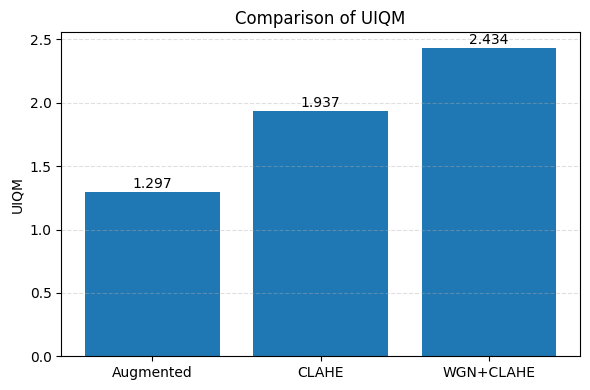

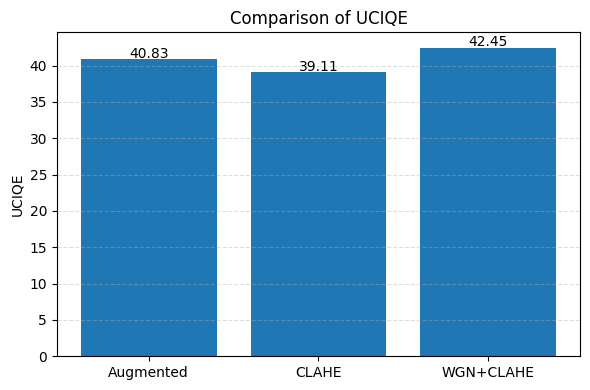

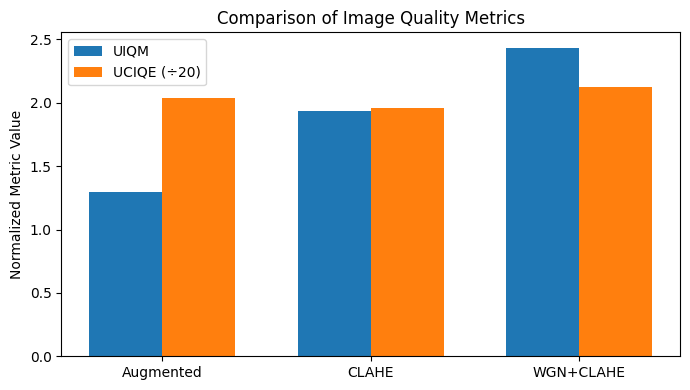

     Dataset   UIQM   UCIQE
0  Augmented  1.297  40.831
1      CLAHE  1.937  39.106
2  WGN+CLAHE  2.434  42.446


In [ ]:
import matplotlib.pyplot as plt

datasets = ["Augmented", "CLAHE", "WGN+CLAHE"]
uiqm = [1.297, 1.937, 2.434]

plt.figure(figsize=(6,4))
plt.bar(datasets, uiqm)
plt.title("Comparison of UIQM")
plt.ylabel("UIQM")
plt.grid(axis='y', linestyle='--', alpha=0.4)

for i, v in enumerate(uiqm):
    plt.text(i, v+0.03, f"{v:.3f}", ha='center')

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Underwater_Project/UIQM_Comparison.png", dpi=300)
plt.show()
uciqe = [40.831, 39.106, 42.446]

plt.figure(figsize=(6,4))
plt.bar(datasets, uciqe)
plt.title("Comparison of UCIQE")
plt.ylabel("UCIQE")
plt.grid(axis='y', linestyle='--', alpha=0.4)

for i, v in enumerate(uciqe):
    plt.text(i, v+0.2, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Underwater_Project/UCIQE_Comparison.png", dpi=300)
plt.show()
import numpy as np

x = np.arange(len(datasets))
width = 0.35

fig, ax1 = plt.subplots(figsize=(7,4))

ax1.bar(x-width/2, uiqm, width, label="UIQM")
ax1.bar(x+width/2, np.array(uciqe)/20, width, label="UCIQE (÷20)")

ax1.set_xticks(x)
ax1.set_xticklabels(datasets)
ax1.set_ylabel("Normalized Metric Value")
ax1.set_title("Comparison of Image Quality Metrics")
ax1.legend()

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Underwater_Project/Combined_Metrics.png", dpi=300)
plt.show()
import pandas as pd

df = pd.DataFrame({
    "Dataset": datasets,
    "UIQM": uiqm,
    "UCIQE": uciqe
})

df.to_csv("/content/drive/MyDrive/Underwater_Project/Image_Quality_Results.csv", index=False)
print(df)

In [ ]:
# =====================================================
# GPU SETUP
# =====================================================

!nvidia-smi

import torch

print("="*60)
print("Torch Version :", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
else:
    raise RuntimeError("GPU NOT FOUND")

# Install CuPy
!pip -q install cupy-cuda12x

import cupy as cp

print("="*60)
print("CuPy Version :", cp.__version__)

# Warm-up GPU
a = cp.arange(1000000)
cp.sum(a)

print("GPU READY")
print("="*60)

/bin/bash: line 1: nvidia-smi: command not found
Torch Version : 2.11.0+cpu
CUDA Available: False


RuntimeError: GPU NOT FOUND

In [ ]:
import os
import cv2
import numpy as np
import cupy as cp

from tqdm import tqdm
import matplotlib.pyplot as plt
import time

INPUT_DIR = "/content/drive/MyDrive/Underwater_Project/datasets/enhanced_wgn_clahe"

OUTPUT_1BIT = "/content/drive/MyDrive/Underwater_Project/datasets/enhanced_wgn_clahe_1bit"

OUTPUT_2BIT = "/content/drive/MyDrive/Underwater_Project/datasets/enhanced_wgn_clahe_2bit"

OUTPUT_3BIT = "/content/drive/MyDrive/Underwater_Project/datasets/enhanced_wgn_clahe_3bit"

os.makedirs(OUTPUT_1BIT, exist_ok=True)
os.makedirs(OUTPUT_2BIT, exist_ok=True)
os.makedirs(OUTPUT_3BIT, exist_ok=True)

ModuleNotFoundError: No module named 'cupy'

In [ ]:
# ============================================================
# GPU RGB Quantization
# ============================================================

def hw_quantize_gpu(img, bits):

    shift = 8 - bits

    return (img >> shift) << shift


# ============================================================
# GPU Process Image
# ============================================================

def process_image_gpu(image):

    # ---------------------------------------------------------
    # Upload image to GPU
    # ---------------------------------------------------------

    gpu = cp.asarray(image)

    # ---------------------------------------------------------
    # RGB -> Gray
    # (same BT.601 coefficients used by OpenCV)
    # ---------------------------------------------------------

    gray = (
        0.114 * gpu[:,:,0] +
        0.587 * gpu[:,:,1] +
        0.299 * gpu[:,:,2]
    ).astype(cp.uint8)

    # ---------------------------------------------------------
    # Histogram
    # ---------------------------------------------------------

    hist = cp.bincount(gray.ravel(), minlength=256)

    total = gray.size

    # ---------------------------------------------------------
    # Prefix sums
    # ---------------------------------------------------------

    cum_sum = cp.cumsum(hist)

    cum_mean = cp.cumsum(hist * cp.arange(256))

    global_mean = cum_mean[-1]

    # ---------------------------------------------------------
    # Vectorized Otsu
    # ---------------------------------------------------------

    w0 = cum_sum

    w1 = total - w0

    valid = (w0 > 0) & (w1 > 0)

    score = cp.zeros(256, dtype=cp.float64)

    score[valid] = (global_mean * w0[valid] - cum_mean[valid]) ** 2

    otsu_thresh = int(cp.argmax(score).get())

    # ---------------------------------------------------------
    # Binary Mask
    # ---------------------------------------------------------

    mask = gray > otsu_thresh

    # ---------------------------------------------------------
    # Segmentation
    # ---------------------------------------------------------

    segmented = gpu.copy()

    segmented[~mask] = 0

    # ---------------------------------------------------------
    # Quantization
    # ---------------------------------------------------------

    img1 = hw_quantize_gpu(segmented,1)

    img2 = hw_quantize_gpu(segmented,2)

    img3 = hw_quantize_gpu(segmented,3)

    # ---------------------------------------------------------
    # Back to CPU
    # ---------------------------------------------------------

    img1 = cp.asnumpy(img1)

    img2 = cp.asnumpy(img2)

    img3 = cp.asnumpy(img3)

    return img1,img2,img3

In [ ]:
# ============================================================
# FIND ALL IMAGES
# ============================================================

image_paths = []

for root, dirs, files in os.walk(INPUT_DIR):

    for file in files:

        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            image_paths.append(os.path.join(root, file))

print("="*60)
print("Total Images Found :", len(image_paths))
print("="*60)

# ============================================================
# GPU PROCESSING
# ============================================================

processed = 0
skipped = 0

# GPU Synchronize before timing
cp.cuda.Stream.null.synchronize()

start = time.perf_counter()

for path in tqdm(image_paths):

    try:

        image = cv2.imread(path)

        if image is None:
            skipped += 1
            continue

        # GPU preprocessing
        img1, img2, img3 = process_image_gpu(image)

        # Preserve folder structure
        rel = os.path.relpath(path, INPUT_DIR)

        out1 = os.path.join(OUTPUT_1BIT, rel)
        out2 = os.path.join(OUTPUT_2BIT, rel)
        out3 = os.path.join(OUTPUT_3BIT, rel)

        os.makedirs(os.path.dirname(out1), exist_ok=True)
        os.makedirs(os.path.dirname(out2), exist_ok=True)
        os.makedirs(os.path.dirname(out3), exist_ok=True)

        cv2.imwrite(out1, img1)
        cv2.imwrite(out2, img2)
        cv2.imwrite(out3, img3)

        processed += 1

    except Exception as e:

        print("\nERROR:", path)
        print(e)

        skipped += 1

# Wait for GPU to finish
cp.cuda.Stream.null.synchronize()

gpu_time = time.perf_counter() - start

print("\n")
print("="*60)
print("GPU PROCESSING COMPLETED")
print("="*60)
print(f"Processed : {processed}")
print(f"Skipped   : {skipped}")
print(f"GPU Time  : {gpu_time:.2f} seconds")
print("="*60)

Total Images Found : 14524


100%|██████████| 14524/14524 [2:34:51<00:00,  1.56it/s]



GPU PROCESSING COMPLETED
Processed : 14524
Skipped   : 0
GPU Time  : 9291.82 seconds


In [ ]:
import matplotlib.pyplot as plt
import cv2
import glob

# Original image
orig_path = glob.glob(INPUT_DIR + "/**/*.jpg", recursive=True)[0]

# Processed images
img1_path = glob.glob(OUTPUT_1BIT + "/**/*.jpg", recursive=True)[0]
img2_path = glob.glob(OUTPUT_2BIT + "/**/*.jpg", recursive=True)[0]
img3_path = glob.glob(OUTPUT_3BIT + "/**/*.jpg", recursive=True)[0]

orig = cv2.cvtColor(cv2.imread(orig_path), cv2.COLOR_BGR2RGB)
img1 = cv2.cvtColor(cv2.imread(img1_path), cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(cv2.imread(img2_path), cv2.COLOR_BGR2RGB)
img3 = cv2.cvtColor(cv2.imread(img3_path), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(20,5))

plt.subplot(1,4,1)
plt.imshow(orig)
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(img1)
plt.title("1-bit")

plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(img2)
plt.title("2-bit")

plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(img3)
plt.title("3-bit")

plt.axis("off")

plt.show()

NameError: name 'INPUT_DIR' is not defined

In [ ]:
!pip install torch torchvision
!pip install scikit-learn
!pip install matplotlib

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torchvision.models import mobilenet_v2

import torch.nn as nn
import torch.optim as optim

In [ ]:
transform = transforms.ToTensor()

In [ ]:
train_dataset = ImageFolder(
    "/content/drive/MyDrive/Underwater_Project/datasets/enhanced_wgn_clahe_3bit/train",
    transform=transform
)

test_dataset = ImageFolder(
    "/content/drive/MyDrive/Underwater_Project/datasets/enhanced_wgn_clahe_3bit/test",
    transform=transform
)

In [ ]:
!pip install -q torch torchvision scikit-learn matplotlib seaborn

In [ ]:
import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torchvision.models import mobilenet_v2
from torch.utils.data import DataLoader

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Device: cuda
Tesla T4


In [ ]:
train_dir = "/content/drive/MyDrive/Underwater_Project/datasets/enhanced_wgn_clahe_3bit/train"

test_dir = "/content/drive/MyDrive/Underwater_Project/datasets/enhanced_wgn_clahe_3bit/test"

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

In [ ]:
train_dataset = datasets.ImageFolder(
    train_dir,
    transform=transform
)

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=transform
)

print("Training Images :", len(train_dataset))
print("Testing Images :", len(test_dataset))

print(train_dataset.classes)

Training Images : 13656
Testing Images : 868
['echinus', 'holothurian', 'scallop', 'starfish']


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)


test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True

)

In [ ]:
model = mobilenet_v2(weights="DEFAULT")

In [ ]:
model.classifier[1] = nn.Linear(
    1280,
    4
)

In [ ]:
model = model.to(device)

print(next(model.parameters()).device)

cuda:0


In [ ]:
criterion = nn.CrossEntropyLoss()

In [ ]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [ ]:
num_epochs = 20

train_losses = []

train_accuracies = []

In [ ]:


num_epochs = 20

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    start_time = time.time()

    for batch_idx, (images, labels) in enumerate(train_loader):

        # Move images and labels to CUDA
        images = images.cuda(non_blocking=True)
        labels = labels.cuda(non_blocking=True)

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Print every 20 batches
        if (batch_idx + 1) % 20 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | Batch {batch_idx+1}/{len(train_loader)}")

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    end_time = time.time()

    print("-"*60)
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Loss     : {epoch_loss:.4f}")
    print(f"Accuracy : {epoch_acc:.2f}%")
    print(f"Time     : {end_time-start_time:.2f} sec")
    print("-"*60)

NameError: name 'model' is not defined

In [ ]:
model.eval()
all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.cuda(non_blocking=True)
        labels = labels.cuda(non_blocking=True)

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

accuracy = accuracy_score(all_labels, all_predictions)

precision = precision_score(
    all_labels,
    all_predictions,
    average='weighted'
)

recall = recall_score(
    all_labels,
    all_predictions,
    average='weighted'
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average='weighted'
)

print("\nEvaluation Results")
print("----------------------")
print(f"Accuracy  : {accuracy*100:.2f}%")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")


Evaluation Results
----------------------
Accuracy  : 85.71%
Precision : 0.8572
Recall    : 0.8571
F1 Score  : 0.8569


<Figure size 800x800 with 0 Axes>

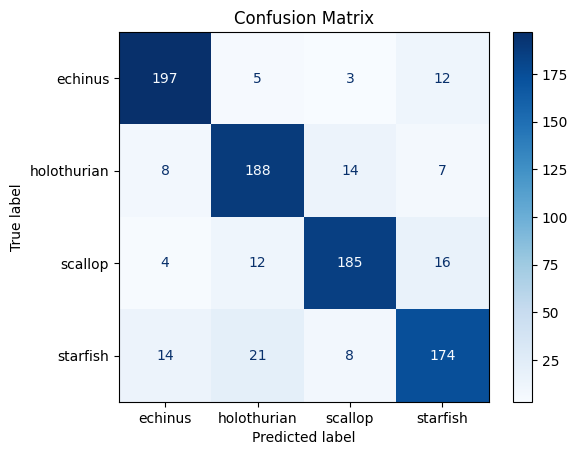

In [ ]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_dataset.classes
)

plt.figure(figsize=(8,8))

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

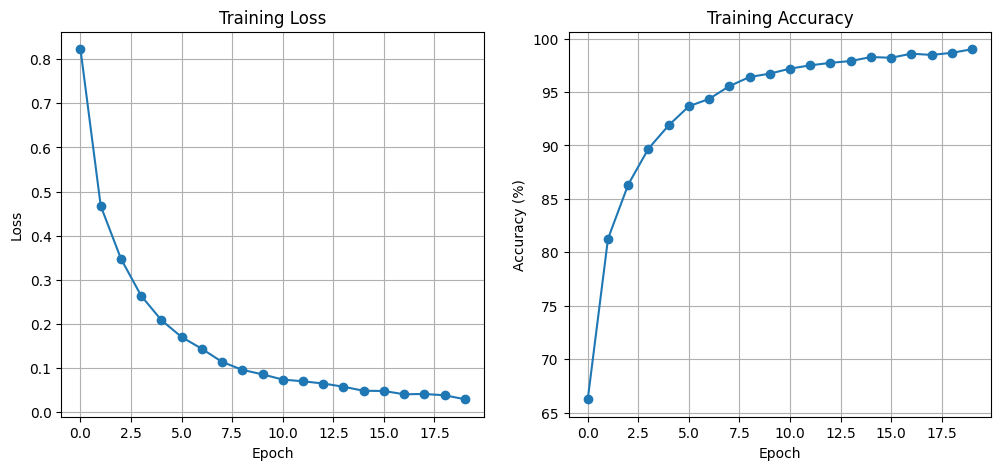

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(train_losses,marker='o')

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.subplot(1,2,2)

plt.plot(train_accuracies,marker='o')

plt.title("Training Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.grid(True)

plt.show()

In [ ]:
torch.save(
    model.state_dict(),
    "mobilenetv2_underwater.pth"
)

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/mobilenetv2_underwater.pth"
)

In [ ]:
from PIL import Image

image_path = "/content/drive/MyDrive/Underwater_Project/datasets/enhanced_wgn_clahe_1bit/test/holothurian/659.jpg"
image = Image.open(image_path).convert("RGB")

image = transform(image)

image = image.unsqueeze(0)

image = image.cuda()

model.eval()

with torch.no_grad():

    output = model(image)

    _, prediction = torch.max(output,1)

print("Predicted Class :", train_dataset.classes[prediction.item()])

Predicted Class : holothurian


In [ ]:
# ============================================================
# SAVE ALL RESULTS
# ============================================================

import os
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

# ------------------------------------------------------------
# CHANGE THIS FOR EACH EXPERIMENT
# original / 1bit / 2bit / 3bit
# ------------------------------------------------------------

RESULTS_DIR = "/content/drive/MyDrive/Underwater_Project/results/3bit"

os.makedirs(RESULTS_DIR, exist_ok=True)

# ------------------------------------------------------------
# Save Model
# ------------------------------------------------------------

torch.save(model.state_dict(),
           os.path.join(RESULTS_DIR, "best_model.pth"))

# ------------------------------------------------------------
# Save Training History
# ------------------------------------------------------------

history = pd.DataFrame({
    "Epoch": range(1, len(train_losses)+1),
    "Train Loss": train_losses,
    "Train Accuracy": train_accuracies
})

history.to_csv(
    os.path.join(RESULTS_DIR, "history.csv"),
    index=False
)

# ------------------------------------------------------------
# Save Metrics
# ------------------------------------------------------------

metrics = pd.DataFrame({
    "Accuracy":[accuracy],
    "Precision":[precision],
    "Recall":[recall],
    "F1 Score":[f1]
})

metrics.to_csv(
    os.path.join(RESULTS_DIR, "metrics.csv"),
    index=False
)

# ------------------------------------------------------------
# Save Classification Report
# ------------------------------------------------------------

report = classification_report(
    all_labels,
    all_predictions,
    target_names=train_dataset.classes
)

with open(
    os.path.join(RESULTS_DIR,
    "classification_report.txt"),
    "w"
) as f:
    f.write(report)

# ------------------------------------------------------------
# Save Accuracy Plot
# ------------------------------------------------------------

plt.figure(figsize=(6,4))
plt.plot(train_accuracies, linewidth=2)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.tight_layout()

plt.savefig(
    os.path.join(RESULTS_DIR,
    "training_accuracy.png"),
    dpi=300
)

plt.close()

# ------------------------------------------------------------
# Save Loss Plot
# ------------------------------------------------------------

plt.figure(figsize=(6,4))
plt.plot(train_losses, linewidth=2)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()

plt.savefig(
    os.path.join(RESULTS_DIR,
    "training_loss.png"),
    dpi=300
)

plt.close()

# ------------------------------------------------------------
# Save Confusion Matrix
# ------------------------------------------------------------

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()

plt.savefig(
    os.path.join(RESULTS_DIR,
    "confusion_matrix.png"),
    dpi=300
)

plt.close()
# ------------------------------------------------------------
# Save Combined Convergence Curve
# ------------------------------------------------------------

plt.figure(figsize=(10,4))

# Loss
plt.subplot(1,2,1)
plt.plot(train_losses, marker='o')
plt.title("Loss Convergence")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

# Accuracy
plt.subplot(1,2,2)
plt.plot(train_accuracies, marker='o')
plt.title("Accuracy Convergence")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(RESULTS_DIR, "convergence_curve.png"),
    dpi=300
)

plt.close()

# ------------------------------------------------------------
# Save Box Plot
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

plt.boxplot(
    [train_losses, train_accuracies],
    labels=["Loss", "Accuracy"]
)

plt.title("Training Metrics Distribution")
plt.ylabel("Value")
plt.grid(True)

plt.savefig(
    os.path.join(RESULTS_DIR, "box_plot.png"),
    dpi=300
)

plt.close()

print("\n===================================")
print(" All Results Saved Successfully")
print("===================================")
print("Location :", RESULTS_DIR)

/tmp/ipykernel_437/3729481751.py:181: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(



 All Results Saved Successfully
Location : /content/drive/MyDrive/Underwater_Project/results/2bit
